# Notebook 01: ODE Model Simulation
Implements the deterministic 5-equation mean-field system, sweeps parameter space, and maps the stability boundary.


### Important Project Safety Notice

Before executing or citing the findings in this notebook, please read the public guidance on what this project is and is not claiming:  

[docs/not_saying.md](../docs/not_saying.md) - *What This Theory Is NOT Claiming*


In [1]:
import sys
sys.path.append('..')
from src.pendulum_model import PendulumSimulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1. Run Standard Scenarios
We load pre-configured scenarios representing different theoretical regimes.


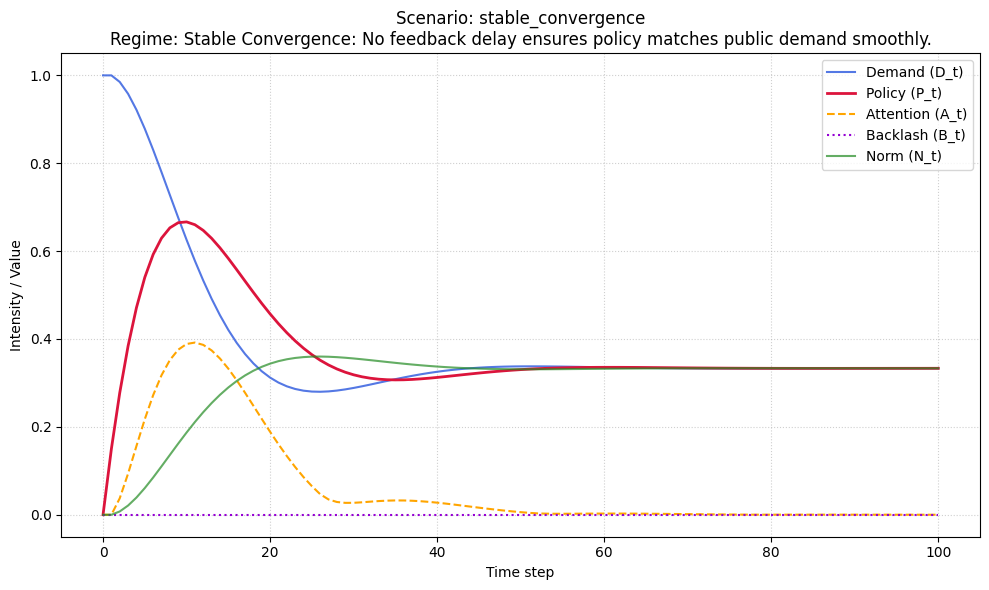

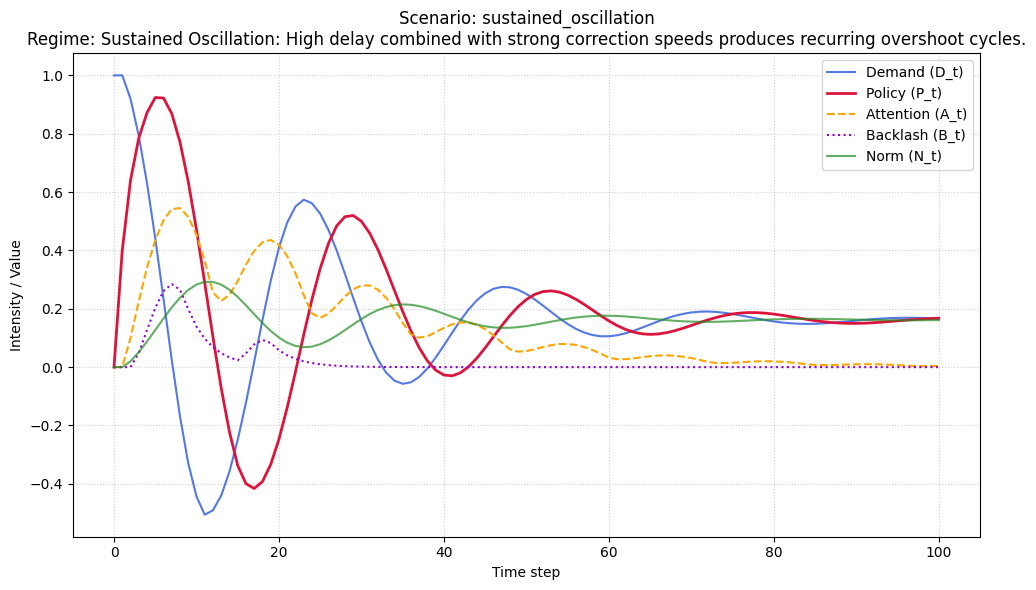

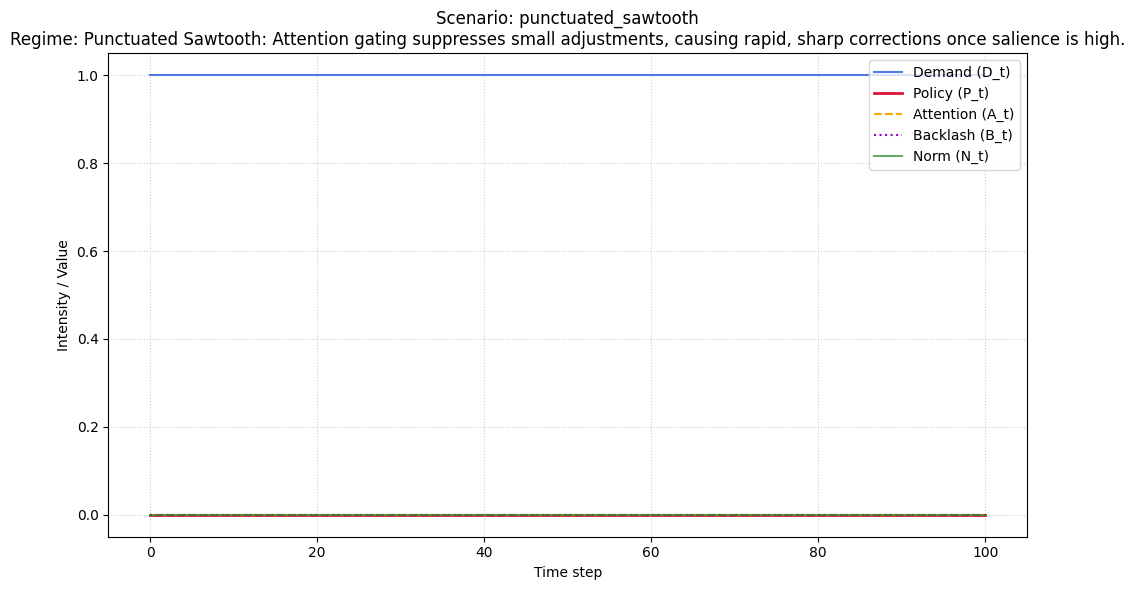

In [2]:
scenarios = ['stable_convergence', 'sustained_oscillation', 'punctuated_sawtooth']
for name in scenarios:
    sim = PendulumSimulation.from_scenario(name)
    sim.run(steps=100)
    fig = sim.plot_time_series(title=f'Scenario: {name}')
    plt.show()


## 2. Stability Boundary Parameter Sweep
We sweep over $\tau$ (delay lag) and $\lambda$ (correction speed) to map the boundary between stable convergence and cycles.


In [3]:
sim = PendulumSimulation(alpha=0.2, nu=0.05)
df_sweep = sim.parameter_sweep(tau_range=list(range(6)), lambda_range=list(np.linspace(0.05, 0.9, 10)))
print(df_sweep.head(10))


   tau    lambda  amplitude_std  sign_changes  final_value      regime
0    0  0.050000   5.263846e-03             3     0.192636  convergent
1    0  0.144444   9.647274e-04             5     0.189568  convergent
2    0  0.238889   8.186878e-05             6     0.188798  convergent
3    0  0.333333   3.216363e-06             8     0.188651  convergent
4    0  0.427778   2.442961e-07             8     0.188743  convergent
5    0  0.522222   4.523163e-09             6     0.188937  convergent
6    0  0.616667   7.179119e-11             5     0.189174  convergent
7    0  0.711111   1.833649e-12             2     0.189423  convergent
8    0  0.805556   8.589483e-15             1     0.189669  convergent
9    0  0.900000   1.980222e-16             0     0.189903  convergent


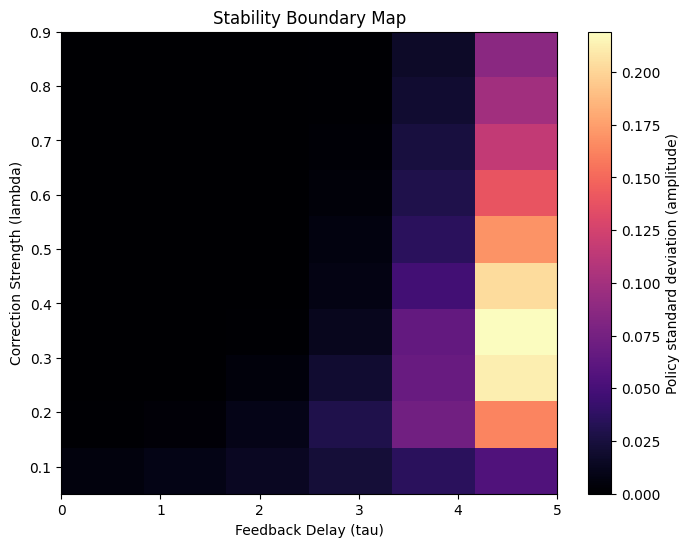

In [4]:
# Plot stability boundary map
pivot = df_sweep.pivot(index='lambda', columns='tau', values='amplitude_std')
plt.figure(figsize=(8, 6))
plt.imshow(pivot, aspect='auto', origin='lower', extent=[0, 5, 0.05, 0.9], cmap='magma')
plt.colorbar(label='Policy standard deviation (amplitude)')
plt.xlabel('Feedback Delay (tau)')
plt.ylabel('Correction Strength (lambda)')
plt.title('Stability Boundary Map')
plt.show()
